# EDA — Dataset muhammadshahidazeem

Dataset de remplacement de rivalytics pour atteindre F1 ≥ 0.70.

**Sources** :
- `data/customer_churn_dataset-training-master.csv` — 440 833 lignes
- `data/customer_churn_dataset-testing-master.csv` — 64 374 lignes

**Objectifs** :
1. Comprendre la structure et la qualité des données
2. Identifier les features discriminantes
3. Définir la stratégie de preprocessing pour la Phase 2

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))

DATA_DIR = Path('../data')
TARGET = 'Churn'

train = pd.read_csv(DATA_DIR / 'customer_churn_dataset-training-master.csv')
test  = pd.read_csv(DATA_DIR / 'customer_churn_dataset-testing-master.csv')

# Suppression de la ligne nulle (1 null par colonne = ligne header malformée)
train = train.dropna(how='all').dropna(subset=[TARGET])
test  = test.dropna(how='all').dropna(subset=[TARGET])

print(f'Train : {train.shape} | Test : {test.shape}')
train.head(3)

Train : (440832, 12) | Test : (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0


## 1. Structure & qualité des données

In [2]:
print('=== TYPES ===')
print(train.dtypes)
print('\n=== VALEURS MANQUANTES ===')
print(train.isnull().sum())
print('\n=== DOUBLONS ===')
print(f'CustomerID uniques : {train["CustomerID"].nunique()} / {len(train)}')
print(f'Doublons complets  : {train.duplicated().sum()}')

=== TYPES ===
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

=== VALEURS MANQUANTES ===


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

=== DOUBLONS ===
CustomerID uniques : 440832 / 440832


Doublons complets  : 0


In [3]:
print('=== VARIABLES CATÉGORIELLES ===')
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    print(f'\n{col} :')
    print(train[col].value_counts())

=== VARIABLES CATÉGORIELLES ===

Gender :
Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type :


Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length :


Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


In [4]:
train.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## 2. Distribution de la cible

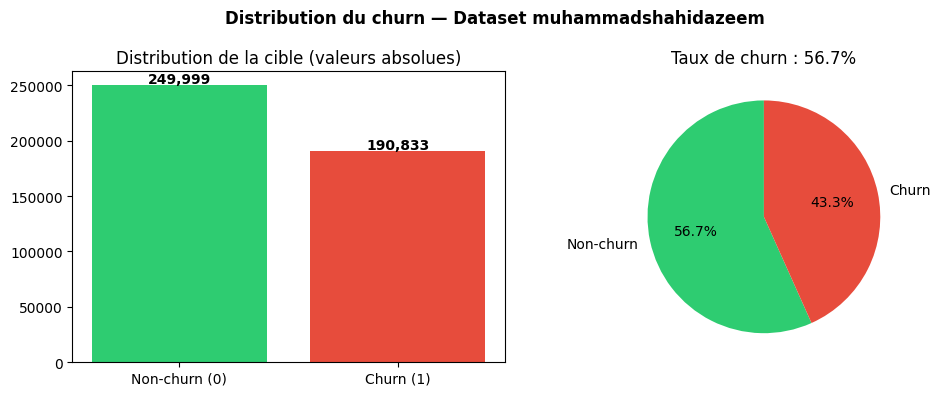

Taux de churn train : 56.71%
Taux de churn test  : 47.37%


In [5]:
churn_counts = train[TARGET].value_counts()
churn_rate = train[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Non-churn (0)', 'Churn (1)'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution de la cible (valeurs absolues)')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Non-churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title(f'Taux de churn : {churn_rate:.1%}')

plt.suptitle('Distribution du churn — Dataset muhammadshahidazeem', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Taux de churn train : {churn_rate:.2%}')
print(f'Taux de churn test  : {test[TARGET].mean():.2%}')

## 3. Features numériques vs churn

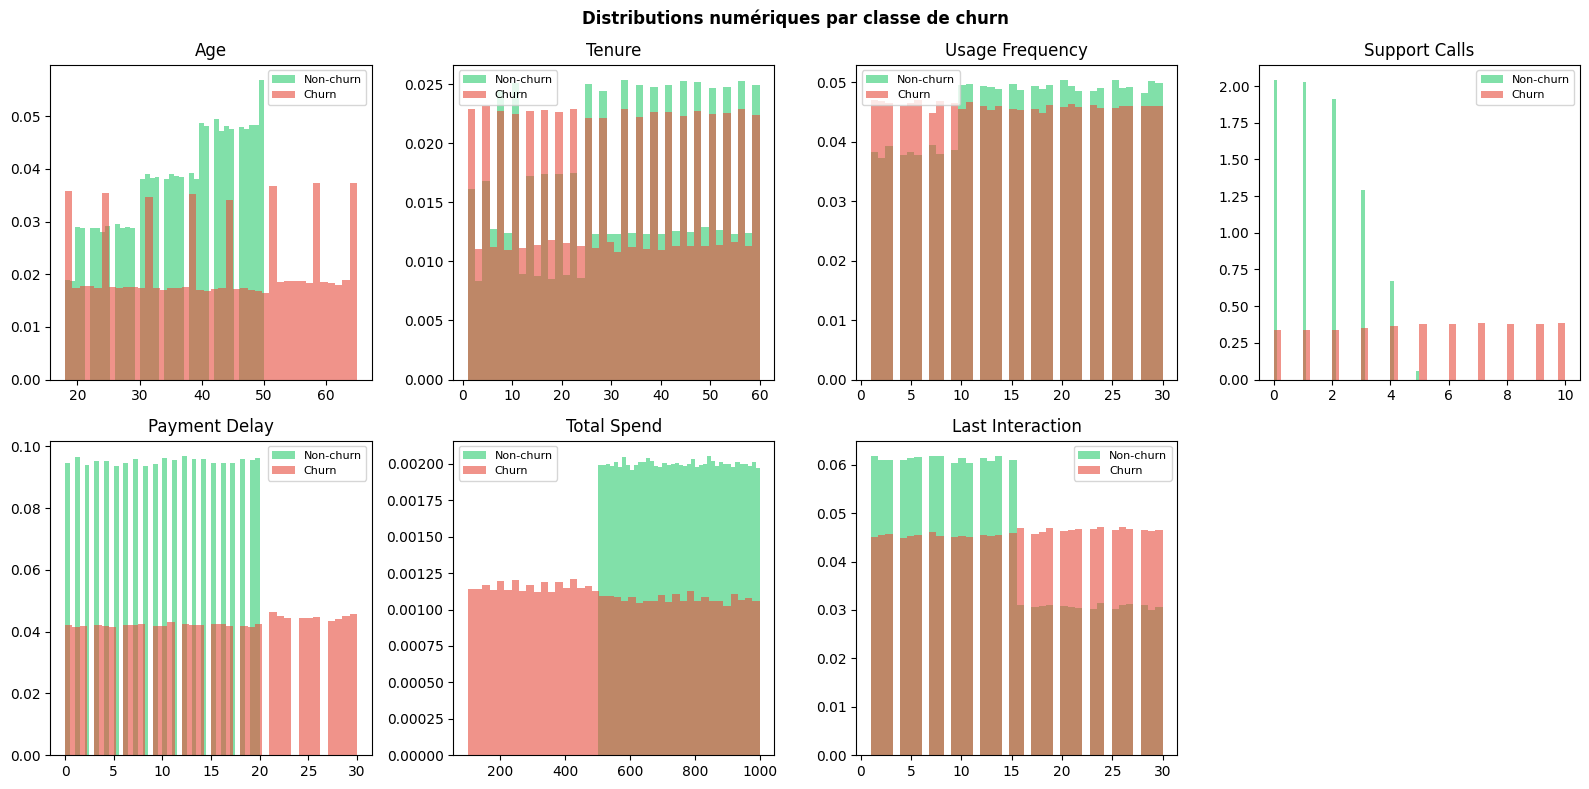

In [6]:
num_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for churn_val, color, label in [(0, '#2ecc71', 'Non-churn'), (1, '#e74c3c', 'Churn')]:
        data = train[train[TARGET] == churn_val][feat].dropna()
        axes[i].hist(data, bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distributions numériques par classe de churn', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Médianes et test de Mann-Whitney
print(f'{'Feature':<22} {'Médiane Non-churn':>20} {'Médiane Churn':>15} {'p-value':>12}')
print('-' * 72)
for feat in num_features:
    g0 = train[train[TARGET] == 0][feat].dropna()
    g1 = train[train[TARGET] == 1][feat].dropna()
    _, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{feat:<22} {g0.median():>20.2f} {g1.median():>15.2f} {p:>12.2e} {sig}')

Feature                   Médiane Non-churn   Médiane Churn      p-value
------------------------------------------------------------------------


Age                                   37.00           42.00     0.00e+00 ***


Tenure                                33.00           30.00    1.05e-257 ***


Usage Frequency                       17.00           15.00    4.72e-202 ***


Support Calls                          1.00            5.00     0.00e+00 ***


Payment Delay                         10.00           15.00     0.00e+00 ***


Total Spend                          749.98          534.00     0.00e+00 ***


Last Interaction                      12.00           16.00     0.00e+00 ***


## 4. Features catégorielles vs churn

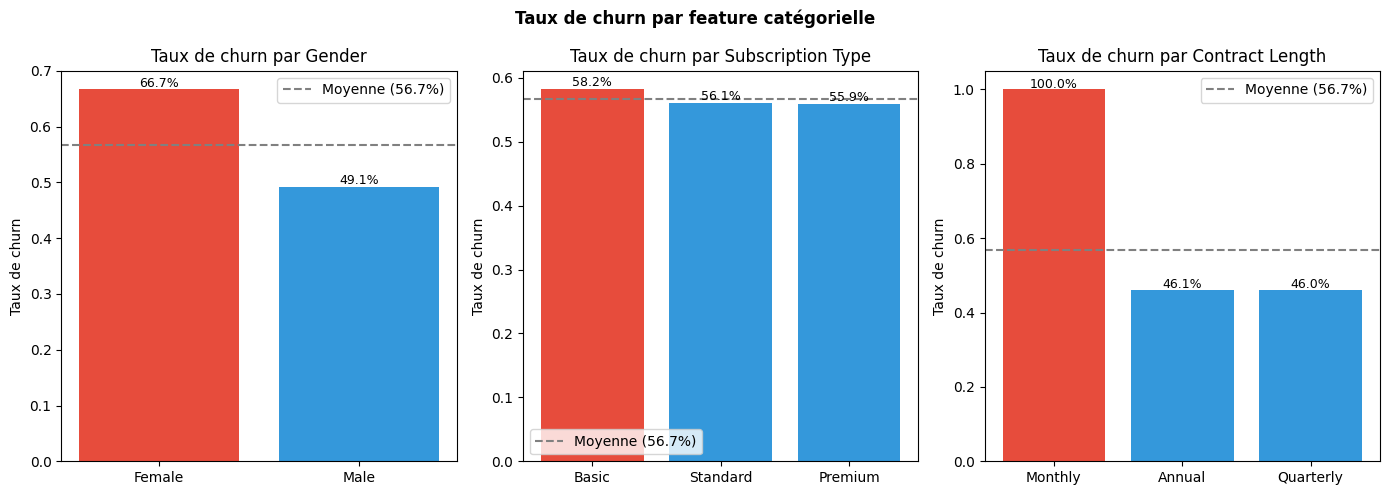

In [8]:
cat_features = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, feat in enumerate(cat_features):
    churn_by_cat = train.groupby(feat)[TARGET].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_by_cat.index, churn_by_cat.values,
                        color=['#e74c3c' if v > churn_rate else '#3498db' for v in churn_by_cat.values])
    axes[i].axhline(churn_rate, color='gray', linestyle='--', label=f'Moyenne ({churn_rate:.1%})')
    axes[i].set_title(f'Taux de churn par {feat}')
    axes[i].set_ylabel('Taux de churn')
    axes[i].legend()
    for bar, val in zip(bars, churn_by_cat.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                     f'{val:.1%}', ha='center', fontsize=9)

plt.suptitle('Taux de churn par feature catégorielle', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Matrice de corrélation

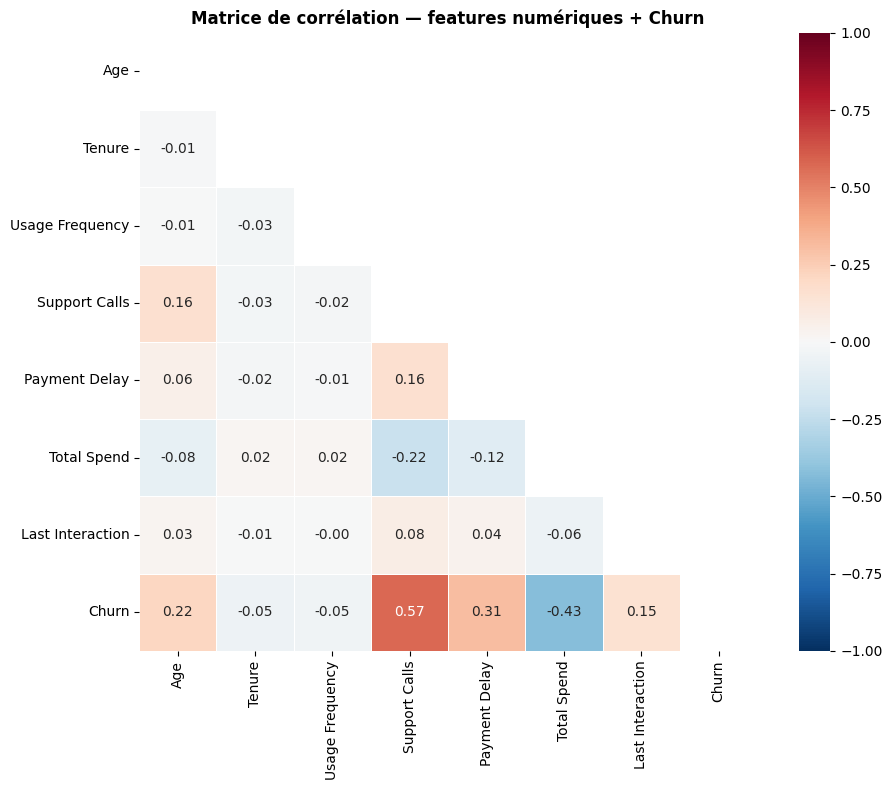


Corrélations avec Churn (Pearson) :
  Support Calls          0.5743
  Total Spend            0.4294
  Payment Delay          0.3121
  Age                    0.2184
  Last Interaction       0.1496
  Tenure                 0.0519
  Usage Frequency        0.0461


In [9]:
corr_df = train[num_features + [TARGET]].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Matrice de corrélation — features numériques + Churn', fontweight='bold')
plt.tight_layout()
plt.show()

# Corrélations avec la cible
print('\nCorrélations avec Churn (Pearson) :')
churn_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
for feat, corr in churn_corr.items():
    print(f'  {feat:<22} {corr:.4f}')

## 6. Outliers

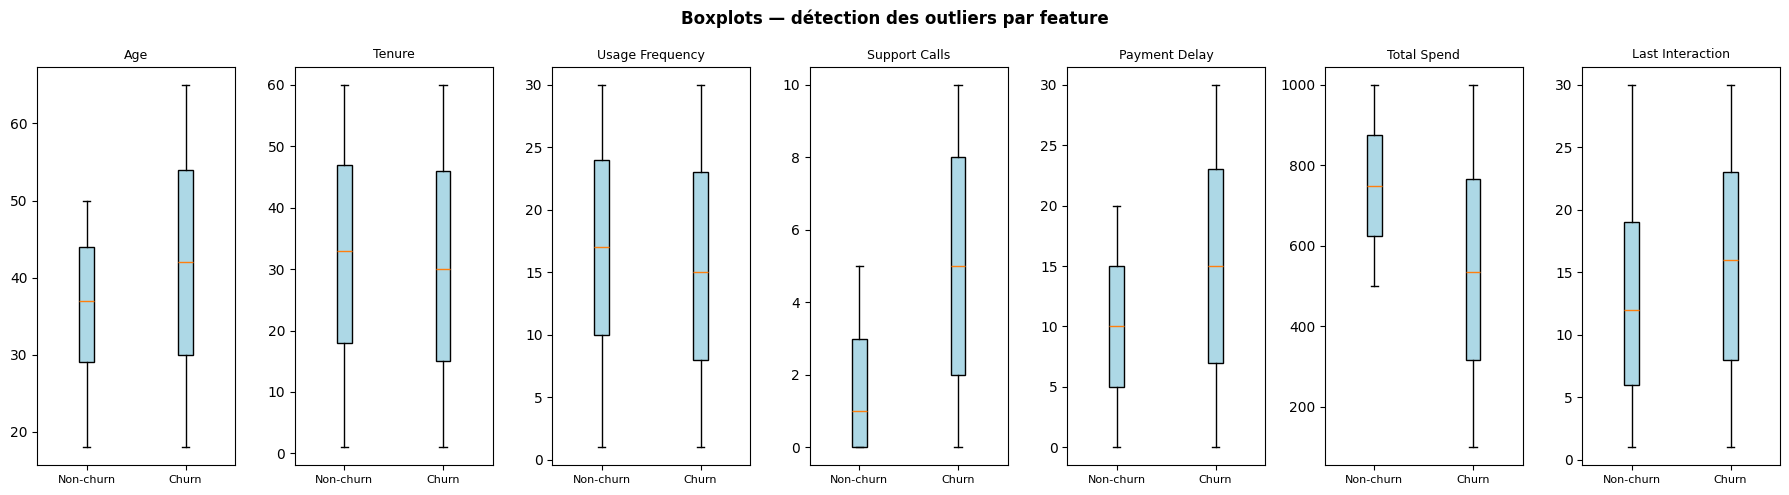

In [10]:
fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))
for ax, feat in zip(axes, num_features):
    ax.boxplot([train[train[TARGET] == 0][feat].dropna(),
                train[train[TARGET] == 1][feat].dropna()],
               labels=['Non-churn', 'Churn'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(feat, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Boxplots — détection des outliers par feature', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Synthèse & recommandations preprocessing

In [11]:
print('=' * 60)
print('SYNTHÈSE EDA — Dataset muhammadshahidazeem')
print('=' * 60)

print(f"""
STRUCTURE
  - Train : {len(train):,} lignes, {train.shape[1]} colonnes
  - Test  : {len(test):,}  lignes, {test.shape[1]} colonnes
  - 1 null par colonne (ligne malformée) → dropped

CIBLE
  - Taux de churn : {train[TARGET].mean():.1%} (vs 22% rivalytics)
  - Quasi-équilibré → scale_pos_weight XGBoost moins critique

FEATURES CATÉGORIELLES
  - Gender           : {train['Gender'].nunique()} modalités
  - Subscription Type: {train['Subscription Type'].nunique()} modalités
  - Contract Length  : {train['Contract Length'].nunique()} modalités

PREPROCESSING RECOMMANDÉ
  1. Drop : CustomerID (identifiant, non prédictif)
  2. Encoder Gender → 0/1 (LabelEncoder)
  3. Encoder Subscription Type → ordinal (Basic < Standard < Premium)
     ou one-hot si non-ordinal confirmé par les corrélations
  4. Encoder Contract Length → ordinal (Monthly < Quarterly < Annual)
  5. StandardScaler sur numériques pour LogReg
  6. Pas de jointure multi-tables (dataset plat)
  7. Train/test déjà splitté → utiliser les fichiers fournis
""")

SYNTHÈSE EDA — Dataset muhammadshahidazeem



STRUCTURE
  - Train : 440,832 lignes, 12 colonnes
  - Test  : 64,374  lignes, 12 colonnes
  - 1 null par colonne (ligne malformée) → dropped

CIBLE
  - Taux de churn : 56.7% (vs 22% rivalytics)
  - Quasi-équilibré → scale_pos_weight XGBoost moins critique

FEATURES CATÉGORIELLES
  - Gender           : 2 modalités
  - Subscription Type: 3 modalités
  - Contract Length  : 3 modalités

PREPROCESSING RECOMMANDÉ
  1. Drop : CustomerID (identifiant, non prédictif)
  2. Encoder Gender → 0/1 (LabelEncoder)
  3. Encoder Subscription Type → ordinal (Basic < Standard < Premium)
     ou one-hot si non-ordinal confirmé par les corrélations
  4. Encoder Contract Length → ordinal (Monthly < Quarterly < Annual)
  5. StandardScaler sur numériques pour LogReg
  6. Pas de jointure multi-tables (dataset plat)
  7. Train/test déjà splitté → utiliser les fichiers fournis



## 8. Train vs test : deux distributions différentes

Le fichier test Kaggle ne suit pas la distribution du train : les non-churners du test ressemblent aux churners du train (Support Calls, Payment Delay). Un modèle entraîné sur le train seul obtient F1 ≈ 0,66 sur le test malgré 0,999 en validation.

**Décision pipeline** : le fichier test devient la *production qui a dérivé* — scindé en `features_incoming.csv` (nouvelles données labellisées) et `features_engineered_test.csv` (hold-out). Evidently détecte la dérive, le DAG réentraîne sur référence + fenêtre récente, promotion si le hold-out s'améliore. Voir `docs/dataset-report.md` §3 et `docs/model-card.md`.

Moyennes par classe (index : fichier, churn)


Support Calls  Payment Delay  Total Spend  Tenure  \
      Churn                                                      
train 0.0             1.59          10.02       749.95   32.28   
      1.0             5.14          15.22       541.29   30.47   
test  0.0             4.50          12.45       560.54   28.83   
      1.0             6.40          22.33       519.34   35.52   

             Usage Frequency    Age  
      Churn                          
train 0.0              16.26  36.26  
      1.0              15.46  41.75  
test  0.0              16.04  41.13  
      1.0              14.01  42.90

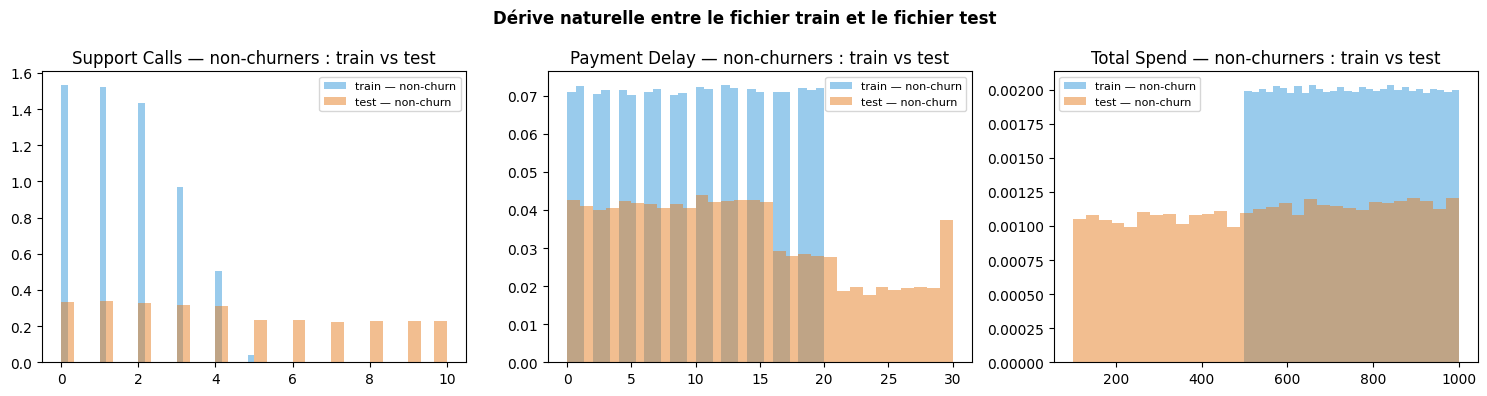

In [12]:
compare_cols = ['Support Calls', 'Payment Delay', 'Total Spend', 'Tenure', 'Usage Frequency', 'Age']
by_class = pd.concat({
    'train': train.groupby(TARGET)[compare_cols].mean(),
    'test': test.groupby(TARGET)[compare_cols].mean(),
}, axis=0).round(2)
print('Moyennes par classe (index : fichier, churn)')
display(by_class)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ['Support Calls', 'Payment Delay', 'Total Spend']):
    for df_, name, color in [(train, 'train', '#3498db'), (test, 'test', '#e67e22')]:
        ax.hist(df_[df_[TARGET] == 0][feat], bins=30, alpha=0.5, density=True, color=color, label=f'{name} — non-churn')
    ax.set_title(f'{feat} — non-churners : train vs test')
    ax.legend(fontsize=8)
plt.suptitle('Dérive naturelle entre le fichier train et le fichier test', fontweight='bold')
plt.tight_layout()
plt.show()
